# MWE 01 — Single-phase flow, porosity, and permeability

Minimal `voids` example using a tiny hand-built network. This notebook runs in the `default` environment.


In [6]:
# Minimal visualization fallback (matplotlib) so this notebook remains dependency-light
import matplotlib.pyplot as plt

from voids.examples import make_linear_chain_network
from voids.physics.petrophysics import (
    absolute_porosity,
    effective_porosity,
    connectivity_metrics,
)
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)

In [7]:
net = make_linear_chain_network()
net

Network(throat_conns=array([[0, 1],
       [1, 2]]), pore_coords=array([[0. , 0. , 0. ],
       [0.5, 0. , 0. ],
       [1. , 0. , 0. ]]), sample=SampleGeometry(voxel_size=None, bulk_shape_voxels=None, bulk_volume=10.0, lengths={'x': 1.0}, cross_sections={'x': 1.0}, axis_map={}, units={'length': 'm', 'pressure': 'Pa'}), provenance=Provenance(source_kind='synthetic_demo', source_version=None, extraction_method='linear_chain', segmentation_notes=None, voxel_size_original=None, image_hash=None, preprocessing_hash=None, random_seed=None, created_at='2026-03-04T06:25:18.455504+00:00', user_notes={'num_pores': 3, 'axis': 'x'}), schema_version='0.1.0', pore={'volume': array([1., 1., 1.])}, throat={'volume': array([0.5, 0.5]), 'length': array([1., 1.]), 'hydraulic_conductance': array([1., 1.])}, pore_labels={'inlet_xmin': array([ True, False, False]), 'outlet_xmax': array([False, False,  True]), 'boundary': array([ True, False,  True])}, throat_labels={}, extra={})

In [8]:
print("phi_abs =", absolute_porosity(net))
print("phi_eff(boundary-connected) =", effective_porosity(net))
print("phi_eff(spanning x) =", effective_porosity(net, axis="x"))
print(connectivity_metrics(net))

phi_abs = 0.4
phi_eff(boundary-connected) = 0.4
phi_eff(spanning x) = 0.4
ConnectivitySummary(n_components=1, giant_component_fraction=1.0, isolated_pore_fraction=0.0, dead_end_fraction=0.6666666666666666, mean_coordination=1.3333333333333333, coordination_histogram={1: 2, 2: 1}, spans={'x': True})


In [9]:
res = solve(
    net,
    fluid=FluidSinglePhase(viscosity=1.0),
    bc=PressureBC("inlet_xmin", "outlet_xmax", pin=1.0, pout=0.0),
    axis="x",
    options=SinglePhaseOptions(conductance_model="generic_poiseuille", solver="direct"),
)
print("Q =", res.total_flow_rate)
print("Kx =", res.permeability["x"])
print("mass balance error =", res.mass_balance_error)

Q = 0.5
Kx = 0.5
mass balance error = 0.0


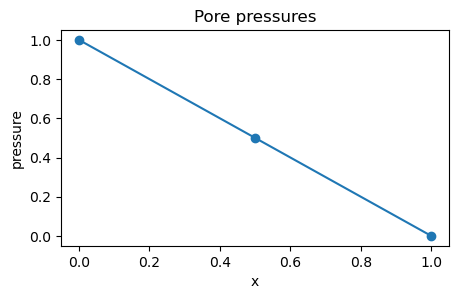

In [10]:
p = res.pore_pressure
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.plot(net.pore_coords[:, 0], p, marker="o")
ax.set_xlabel("x")
ax.set_ylabel("pressure")
ax.set_title("Pore pressures")
plt.show()